# HW05: Word Embeddings

Remember that these homework work as a completion grade. **You can <span style="color:red">not</span> skip one section this homework.**

**Training word2vec**

In this section, we train a word2vec model using gensim. We train the model on text8 (which consists of the first 90M characters of a Wikipedia dump from 2006 and is considered one of the benchmarks for evaluating language models).

In [2]:
!pip install torch
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.7 MB/s eta 0:00:00


In [3]:
import gensim.downloader as api

api.info("text8")

{'num_records': 1701,
 'record_format': 'list of str (tokens)',
 'file_size': 33182058,
 'reader_code': 'https://github.com/RaRe-Technologies/gensim-data/releases/download/text8/__init__.py',
 'license': 'not found',
 'description': 'First 100,000,000 bytes of plain text from Wikipedia. Used for testing purposes; see wiki-english-* for proper full Wikipedia datasets.',
 'checksum': '68799af40b6bda07dfa47a32612e5364',
 'file_name': 'text8.gz',
 'read_more': ['http://mattmahoney.net/dc/textdata.html'],
 'parts': 1}

In [4]:
dataset = api.load("text8")

[==================================================] 100.0% 31.6/31.6MB downloaded


In [5]:
from gensim.models import Word2Vec

##TODO train a word2vec model on this dataset which appear at least 10 times in the corpus
model = Word2Vec(
    sentences=dataset,
    vector_size=100,
    window=5,
    min_count=10,
    workers=4
)

**Word Similarities**

gensim models provide almost all the utility you might want to wish for to perform standard word similarity tasks. They are available in the .wv (wordvectors) attribute of the model, more details could be found [here](https://radimrehurek.com/gensim/models/keyedvectors.html).

In [6]:
model.wv

##TODO find the closest words to king
model.wv.most_similar("king", topn=10)

[('prince', 0.7438092827796936),
 ('throne', 0.6936805248260498),
 ('emperor', 0.6896851658821106),
 ('queen', 0.6878432035446167),
 ('regent', 0.681434154510498),
 ('kings', 0.672865629196167),
 ('vii', 0.6667748093605042),
 ('aragon', 0.6554503440856934),
 ('viii', 0.6496242880821228),
 ('pharaoh', 0.6472782492637634)]

King is to man as woman is to X

In [7]:
##TODO find the closest word for the vector "woman" + "king" - "man"
model.wv.most_similar(positive=["woman", "king"], negative=["man"], topn=5)

[('empress', 0.6464740633964539),
 ('queen', 0.6354171633720398),
 ('son', 0.6068334579467773),
 ('daughter', 0.5995160937309265),
 ('princess', 0.5988059043884277)]

**Evaluate Word Similarities**

One common way to evaluate word2vec models are word analogy tasks. Let's check how good our model is on one of those. We consider the [WordSim353](https://gabrilovich.com/resources/data/wordsim353/wordsim353.html) benchmark, the task is to determine how similar two words are.

In [8]:
!wget https://github.com/CallMeJiaGu/WordSimilarityAnalogyData/raw/refs/heads/master/ws353simrel.tar.gz
!tar xf ws353simrel.tar.gz

path = "wordsim353_sim_rel/wordsim_similarity_goldstandard.txt"

def load_data(path):
    X, y = [], []
    with open(path) as f:
        for line in f:
            line = line.strip().split("\t")
            X.append((line[0], line[1])) # each entry in x contains two words, e.g. X[0] = (tiger, cat)
            y.append(float(line[-1])) # each entry in y is the annotation how similar two words are, e.g. Y[0] = 7.35
    return X, y

X, y = load_data(path)
print (X[:3], y[:3])

--2026-03-02 22:55:19--  https://github.com/CallMeJiaGu/WordSimilarityAnalogyData/raw/refs/heads/master/ws353simrel.tar.gz
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/CallMeJiaGu/WordSimilarityAnalogyData/refs/heads/master/ws353simrel.tar.gz [following]
--2026-03-02 22:55:19--  https://raw.githubusercontent.com/CallMeJiaGu/WordSimilarityAnalogyData/refs/heads/master/ws353simrel.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5460 (5.3K) [application/octet-stream]
Saving to: ‘ws353simrel.tar.gz’

ws353simrel.tar.gz  100%[===================>]   5.33K  --.-KB/s    in 0s      

2026-03-0

In [9]:
##TODO compute how similar the pairs in the WordSim353 are according to our model
# if a word is not present in our model, we assign similarity 0 for the respective text pair

import numpy as np

predictions = []

for w1, w2 in X:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
    else:
        sim = 0
    predictions.append(sim)

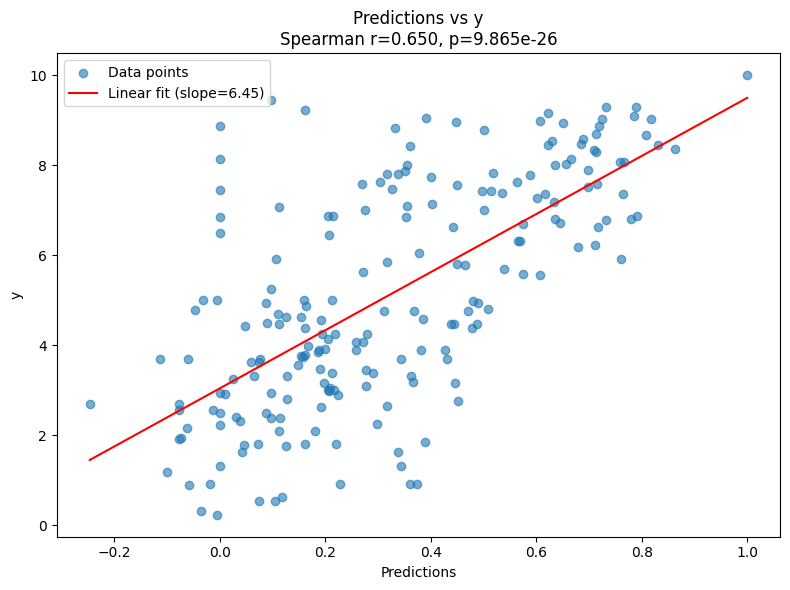

In [10]:
from scipy.stats import spearmanr

##TODO compute spearman's rank correlation between our prediction and the human annotations
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr, linregress

# compute correlation
corr, p_value = spearmanr(predictions, y)

# linear fit
slope, intercept, r, p, se = linregress(predictions, y)
x_line = np.linspace(min(predictions), max(predictions), 100)
y_line = slope * x_line + intercept

# plot
plt.figure(figsize=(8, 6))
plt.scatter(predictions, y, alpha=0.6, label='Data points')
plt.plot(x_line, y_line, color='red', label=f'Linear fit (slope={slope:.2f})')
plt.xlabel('Predictions')
plt.ylabel('y')
plt.title(f'Predictions vs y\nSpearman r={corr:.3f}, p={p_value:.3e}')
plt.legend()
plt.tight_layout()
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 22.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Spearman correlation: 0.40832613330498274
p-value: 1.471099480766231e-09


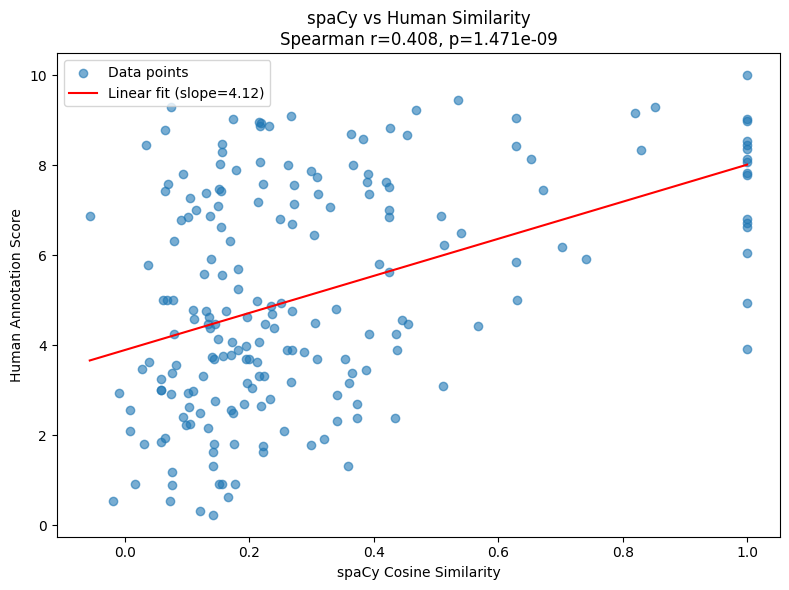

In [12]:
import spacy
!python -m spacy download en_core_web_md
en = spacy.load('en_core_web_md')

##TODO compute word similarities in the WordSim353 dataset using spaCy word embeddings
##TODO compute spearman's rank correlation between these similarities and the human annotations
# Don't worry if results are not too convincing for this experiment

# compute word similarities using spaCy embeddings
predictions = []
for word1, word2 in X:
    token1 = en(word1)[0]
    token2 = en(word2)[0]
    predictions.append(token1.similarity(token2))  # cosine similarity between word vectors

# compute spearman correlation
corr, p_value = spearmanr(predictions, y)
print("Spearman correlation:", corr)
print("p-value:", p_value)

# plot
slope, intercept, *_ = linregress(predictions, y)
x_line = np.linspace(min(predictions), max(predictions), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(8, 6))
plt.scatter(predictions, y, alpha=0.6, label='Data points')
plt.plot(x_line, y_line, color='red', label=f'Linear fit (slope={slope:.2f})')
plt.xlabel('spaCy Cosine Similarity')
plt.ylabel('Human Annotation Score')
plt.title(f'spaCy vs Human Similarity\nSpearman r={corr:.3f}, p={p_value:.3e}')
plt.legend()
plt.tight_layout()
plt.show()

**PyTorch Embeddings**

In [ ]:
#Import the AG news dataset (same as hw01)
#Download them from here
!wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv

import pandas as pd
import nltk
df = pd.read_csv('train.csv')

df.columns = ["label", "title", "lead"]
label_map = {1:"world", 2:"sport", 3:"business", 4:"sci/tech"}
def replace_label(x):
	return label_map[x]
df["label"] = df["label"].apply(replace_label)
df["text"] = df["title"] + " " + df["lead"]
df = df.sample(n=10000) # # only use 10K datapoints
df.head()

--2026-03-02 17:41:14--  https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29470338 (28M) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]  28.10M   173MB/s    in 0.2s    

2026-03-02 17:41:15 (173 MB/s) - ‘train.csv’ saved [29470338/29470338]



,label,title,lead,text
1058,sport,Lightning Reacquire Prospal From Ducks (AP),AP - Vaclav Prospal is returning to the Stanle...,Lightning Reacquire Prospal From Ducks (AP) AP...
12722,sport,Ramirez injured as Red Sox beat Tigers 5-3 for...,Manny Ramirez banged a ball off his knee. Keit...,Ramirez injured as Red Sox beat Tigers 5-3 for...
21059,business,U.S. Stocks Close Higher as Crude Falls,&lt;p&gt;&lt;/p&gt;&lt;p&gt; By Megan Davies&l...,U.S. Stocks Close Higher as Crude Falls &lt;p&...
63981,business,Man charged with extorting Hardee #39;s,A stock analyst faces federal charges for tryi...,Man charged with extorting Hardee #39;s A stoc...
26349,sci/tech,Columnists: I Spy With My Little Eye,Forget Congress' myopic efforts to outlaw spyw...,Columnists: I Spy With My Little Eye Forget Co...


In [ ]:
import torch
import torch.nn as nn
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from collections import Counter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
##TODO tokenize the text, only keep 200 most frequent words

X = df["text"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vocab_size = 200

# Step 1: Tokenize Data
train_tokens = [word_tokenize(sample.lower()) for sample in X_train]
test_tokens  = [word_tokenize(sample.lower()) for sample in X_test]

# Step 2: Create Vocabulary
min_freq = 5
counter = Counter(token for sample in train_tokens for token in sample)

# <unk> = 0, <pad> = 1, then all words with frequency >= min_freq
word2idx = {"<unk>": 0, "<pad>": 1}
for word, count in counter.most_common(200):
    if count >= min_freq:
        word2idx[word] = len(word2idx)

unk_index = torch.tensor(0)
pad_index = torch.tensor(1)

def lookup(token):
    return word2idx.get(token, 0)

# Step 3: Numericalize Labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test  = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
#TODO create a one_hot representation for each word and truncate/pad the sequences such that they are all of the same length

# Step 4: Create Data Loaders
from torch.utils.data import DataLoader

def collate_fn(batch):
    sequences = [item[0] for item in batch]
    labels    = [item[1] for item in batch]
    sequences_padded = torch.nn.utils.rnn.pad_sequence(sequences,
                                                       padding_value=pad_index,
                                                       batch_first=True)
    labels = torch.stack(labels)
    return sequences_padded, labels

train_dataset = [(torch.tensor([lookup(t) for t in tokens]), torch.tensor(label))
                 for tokens, label in zip(train_tokens, y_train)]
test_dataset  = [(torch.tensor([lookup(t) for t in tokens]), torch.tensor(label))
                 for tokens, label in zip(test_tokens, y_test)]

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, collate_fn=collate_fn)


In [ ]:
##TODO create your torch embedding like we did in notebook 5! (hint: predicting labels: world, sport, business, and sci/tech)

# Step 5: Embedding Classifier
class EmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=1)  # ignore <pad> in gradients
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)       # [batch, seq_len, embed_dim]
        pooled   = embedded.mean(dim=1)    # average over tokens → [batch, embed_dim]
        return self.fc(pooled)             # [batch, num_classes]

model = EmbeddingClassifier(vocab_size=len(word2idx), embed_dim=64, num_classes=num_classes)

# Step 6: Training Loop
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

for epoch in range(20):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_acc = evaluate(train_loader)
    test_acc  = evaluate(test_loader)
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.3f} | Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")

Epoch 1 | Loss: 1.371 | Train Acc: 0.449 | Test Acc: 0.440
Epoch 2 | Loss: 1.323 | Train Acc: 0.456 | Test Acc: 0.441
Epoch 3 | Loss: 1.250 | Train Acc: 0.602 | Test Acc: 0.590
Epoch 4 | Loss: 1.158 | Train Acc: 0.629 | Test Acc: 0.617
Epoch 5 | Loss: 1.069 | Train Acc: 0.643 | Test Acc: 0.643
Epoch 6 | Loss: 0.990 | Train Acc: 0.664 | Test Acc: 0.661
Epoch 7 | Loss: 0.925 | Train Acc: 0.683 | Test Acc: 0.677
Epoch 8 | Loss: 0.881 | Train Acc: 0.693 | Test Acc: 0.680
Epoch 9 | Loss: 0.838 | Train Acc: 0.701 | Test Acc: 0.688
Epoch 10 | Loss: 0.815 | Train Acc: 0.708 | Test Acc: 0.695
Epoch 11 | Loss: 0.789 | Train Acc: 0.716 | Test Acc: 0.697
Epoch 12 | Loss: 0.772 | Train Acc: 0.720 | Test Acc: 0.704
Epoch 13 | Loss: 0.755 | Train Acc: 0.723 | Test Acc: 0.707
Epoch 14 | Loss: 0.745 | Train Acc: 0.728 | Test Acc: 0.707
Epoch 15 | Loss: 0.732 | Train Acc: 0.729 | Test Acc: 0.708
Epoch 16 | Loss: 0.724 | Train Acc: 0.735 | Test Acc: 0.715
Epoch 17 | Loss: 0.711 | Train Acc: 0.736 | Test 